In [27]:
import pandas as pd 
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0, ResNet101V2, MobileNetV2
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import models ,layers
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Average, Input,Lambda

from sklearn.utils.class_weight import compute_class_weight

In [2]:
data_dir="raw_data/Merged Dataset"

In [3]:
image_path=[os.path.join(root,file)
               for  root ,dirs,files in os.walk(data_dir)
                for file in files
                    if file.lower().endswith(('.jpg','.png'))
           ]
labels=[os.path.basename(os.path.dirname(p)) for p in image_path]

df=pd.DataFrame({
    'file_path':[str(p) for p in image_path],
    'label':labels
})

In [4]:
print(f"the total images:{len(df)}")
print(f"the total class :{df["label"].nunique()}")

the total images:79084
the total class :88


C:\Users\Someshwar Kumbar\AppData\Local\Temp\ipykernel_7084\2244290471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


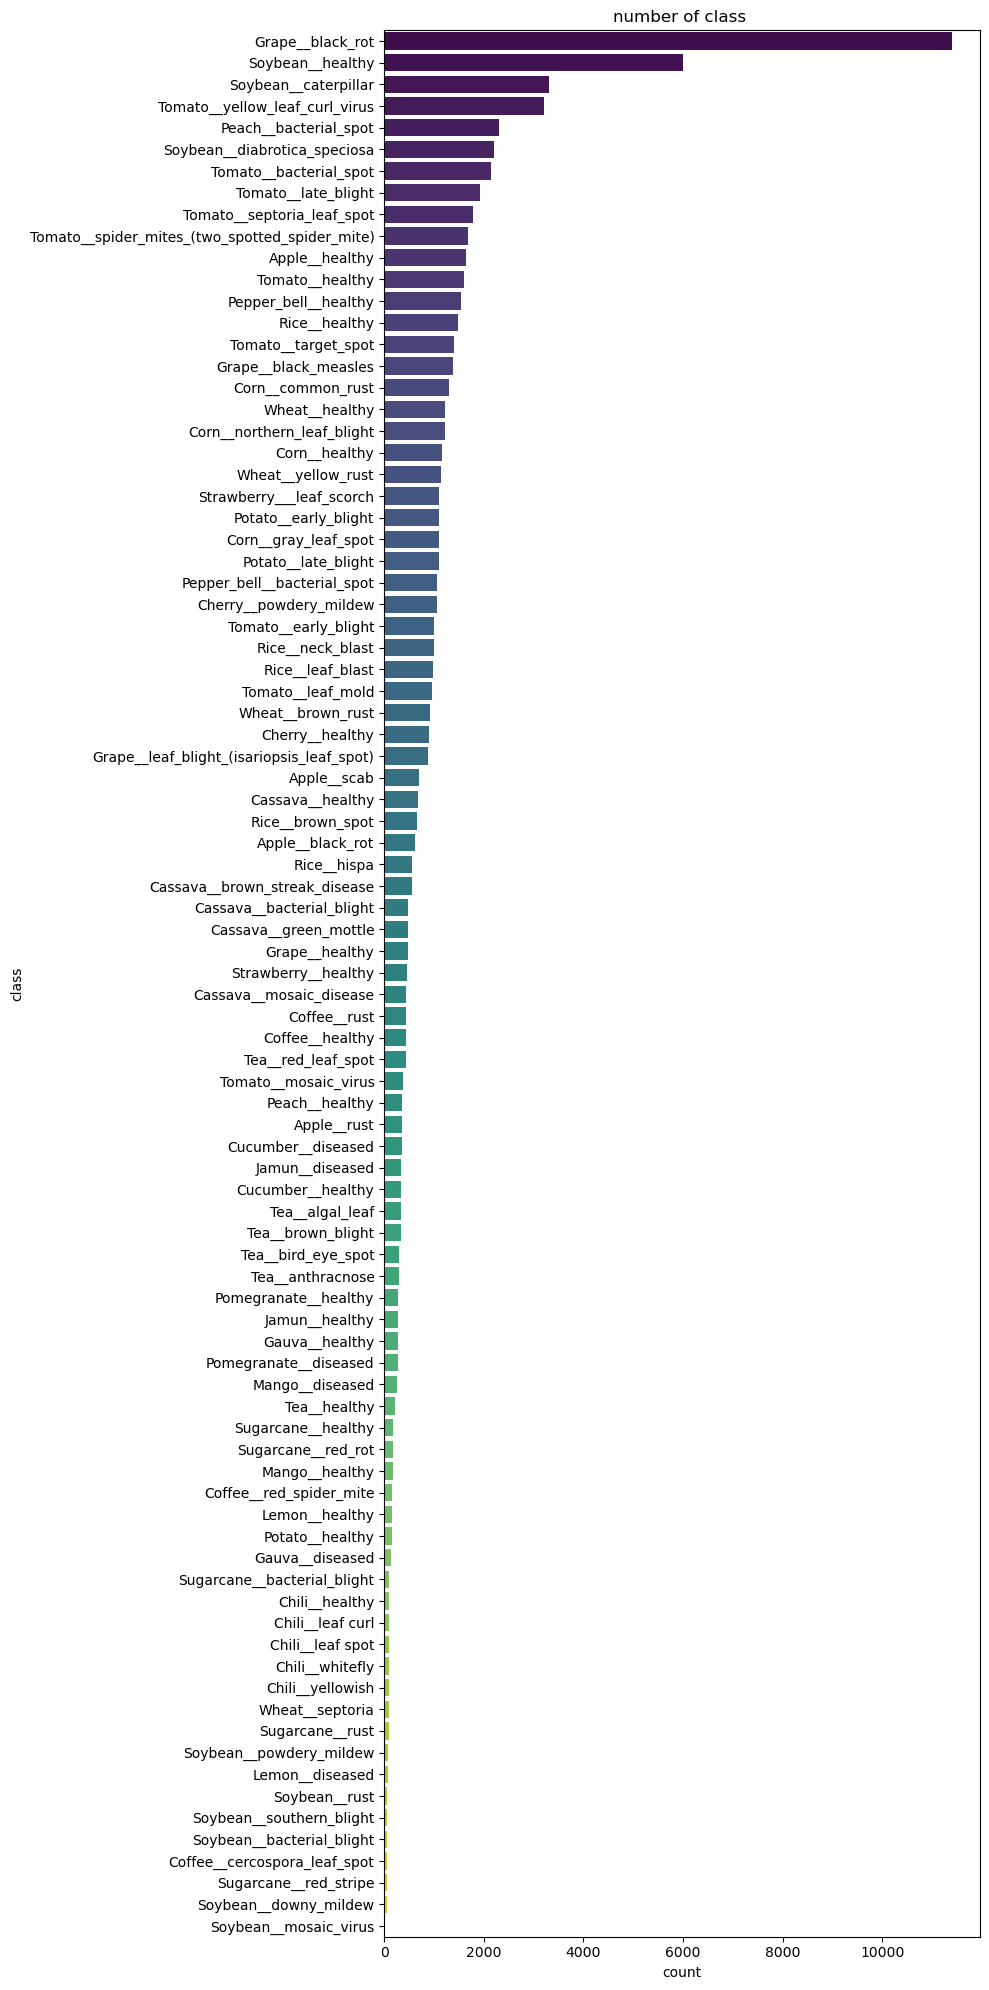

In [5]:
### let's plot calss distrubution table
plt.figure(figsize=(10,20))
sns.countplot(
    data=df,
    y='label',
    order=df['label'].value_counts().index,
    palette='viridis'
)
plt.title("number of class ")
plt.xlabel("count")
plt.ylabel("class")
plt.tight_layout()


In [26]:
##let's fix the photo size and configering
config={
    'image_size':224,
    'batch_size':128,
    'epochs':15,
    'seed':42,
    'model_names':['EfficientNetV2B0', 'ResNet101V2', 'MobileNetV2'],
    'learing_rate':1e-4,
    'dropout_rate':0.3,
     'l2_regularization_rate': 0.001
}

In [7]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(config['seed'])

# Mixed Precision
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print(mixed_precision)

<module 'keras.mixed_precision' from 'C:\\Users\\Someshwar Kumbar\\anaconda3\\Lib\\site-packages\\keras\\mixed_precision\\__init__.py'>


In [8]:
used_classes = [
 'Apple__black_rot',
 'Apple__healthy',
 'Apple__rust',
 'Apple__scab',
 'Cassava__bacterial_blight',
 'Cassava__brown_streak_disease',
 'Cassava__green_mottle',
 'Cassava__healthy',
 'Cassava__mosaic_disease',
 'Cherry__healthy',
 'Cherry__powdery_mildew',
 'Chili__healthy',
 'Chili__leaf curl',
 'Chili__leaf spot',
 'Chili__whitefly',
 'Chili__yellowish',
 'Coffee__cercospora_leaf_spot',
 'Coffee__healthy',
 'Coffee__red_spider_mite',
 'Coffee__rust',
 'Corn__common_rust',
 'Corn__gray_leaf_spot',
 'Corn__healthy',
 'Corn__northern_leaf_blight',
 'Cucumber__diseased',
 'Cucumber__healthy',
 'Gauva__diseased',
 'Gauva__healthy',
 'Grape__black_measles',
 'Grape__black_rot',
 'Grape__healthy',
 'Grape__leaf_blight_(isariopsis_leaf_spot)',
 'Jamun__diseased',
 'Jamun__healthy',
 'Lemon__diseased',
 'Lemon__healthy',
 'Mango__diseased',
 'Mango__healthy',
 'Peach__bacterial_spot',
 'Peach__healthy',
 'Pepper_bell__bacterial_spot',
 'Pepper_bell__healthy',
 'Pomegranate__diseased',
 'Pomegranate__healthy',
 'Potato__early_blight',
 'Potato__healthy',
 'Potato__late_blight',
 'Rice__brown_spot',
 'Rice__healthy',
 'Rice__hispa',
 'Rice__leaf_blast',
 'Rice__neck_blast',
 'Soybean__bacterial_blight',
 'Soybean__caterpillar',
 'Soybean__diabrotica_speciosa',
 'Soybean__downy_mildew',
 'Soybean__healthy',
 'Soybean__mosaic_virus',
 'Soybean__powdery_mildew',
 'Soybean__rust',
 'Soybean__southern_blight',
 'Strawberry___leaf_scorch',
 'Strawberry__healthy',
 'Sugarcane__bacterial_blight',
 'Sugarcane__healthy',
 'Sugarcane__red_rot',
 'Sugarcane__red_stripe',
 'Sugarcane__rust',
 'Tea__algal_leaf',
 'Tea__anthracnose',
 'Tea__bird_eye_spot',
 'Tea__brown_blight',
 'Tea__healthy',
 'Tea__red_leaf_spot',
 'Tomato__bacterial_spot',
 'Tomato__early_blight',
 'Tomato__healthy',
 'Tomato__late_blight',
 'Tomato__leaf_mold',
 'Tomato__mosaic_virus',
 'Tomato__septoria_leaf_spot',
 'Tomato__spider_mites_(two_spotted_spider_mite)',
 'Tomato__target_spot',
 'Tomato__yellow_leaf_curl_virus',
 'Wheat__brown_rust',
 'Wheat__healthy',
 'Wheat__septoria',
 'Wheat__yellow_rust']
n_classes = len(used_classes)

In [9]:
n_classes

88

In [10]:
df =df[df['label'].isin(used_classes).reset_index(drop=True)]
len(df)

79084

In [11]:
df.describe()

,file_path,label
count,79084,79084
unique,79084,88
top,raw_data/Merged Dataset\Apple__black_rot\0090d...,Grape__black_rot
freq,1,11390


In [12]:
##let's do train test split 
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=config['seed'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config['seed'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 55358 | Val: 11863 | Test: 11863


In [13]:
# lets do traing dataset with labels and do augmentation
train_data=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

val_data=ImageDataGenerator(rescale=1./255)
test_data=ImageDataGenerator(rescale=1./255)


##let's genertors

train_gen=train_data.flow_from_dataframe(
    train_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
    seed=config['seed']
)

val_gen=train_data.flow_from_dataframe(
    val_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
)

test_gen=train_data.flow_from_dataframe(
    test_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
)

Found 55358 validated image filenames belonging to 88 classes.
Found 11863 validated image filenames belonging to 88 classes.
Found 11863 validated image filenames belonging to 88 classes.


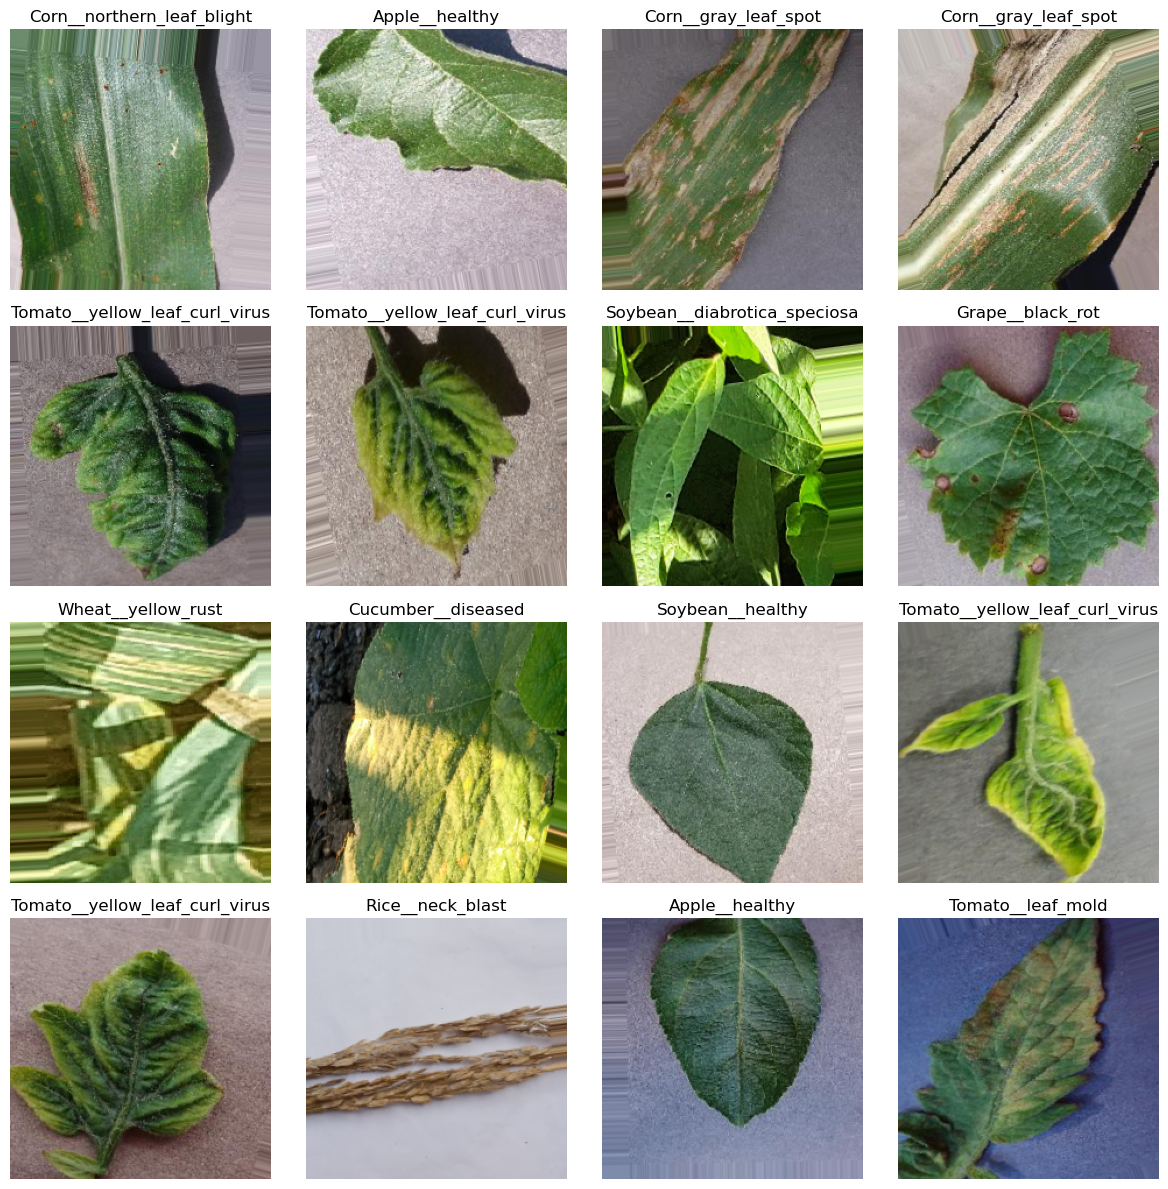

In [14]:
###let's plot some samples
image , labels= next(train_gen)
class_name= list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(image[i])
    label_index = tf.argmax(labels[i]).numpy()
    plt.title(class_name[label_index], fontsize=12)
    plt.axis("off")
plt.tight_layout()

In [15]:
#### now dataset is ready lets train an model with all the base model 
def build_model(base_model_name='EfficientNet', input_shape=(224, 224, 3), n_classes=18):
    if base_model_name == 'EfficientNet':
        base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet':
        base_model = ResNet101V2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'MobileNet':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported base model.")

    base_model.trainable=True

        ### buliding model
        
    model=models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(config['dropout_rate']),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(config['l2_regularization_rate'])),
        layers.Dropout(config['dropout_rate']),
        layers.Dense(n_classes, activation='softmax')
            
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(config['learing_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
model_eff_net=build_model('EfficientNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

In [17]:
modle_res_net=build_model('ResNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

modle_mobile_net=build_model('MobileNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

In [18]:
model_eff_net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)       │ (None, 7, 7, 1280)          │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 88)                  │          22,616 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,269,864 (23.92 MB)

 Trainable params: 6,209,256 (23.69 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [19]:
modle_mobile_net.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 88)                  │          22,616 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,608,536 (9.95 MB)

 Trainable params: 2,574,424 (9.82 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [20]:
modle_res_net.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet101v2 (Functional)             │ (None, 7, 7, 2048)          │      42,626,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 88)                  │          22,616 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,173,720 (164.69 MB)

 Trainable params: 43,076,056 (164.32 MB)

 Non-trainable params: 97,664 (381.50 KB)

In [21]:
### let'set all early stropping
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f"{model_name}_best.keras", monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_lr=1.25e-5, patience=2, verbose=1)
    ]


In [22]:
###let's fix calss imbalance
# Get class indices
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}
train_df['label_idx'] = train_df['label'].map(class_indices)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)

# Convert to dict
class_weights = {i: w for i, w in enumerate(class_weights)}


In [23]:
class_weights

{0: np.float64(2.9955627705627705),
 1: np.float64(0.07889980958462083),
 2: np.float64(0.8201671210145787),
 3: np.float64(0.6498638241923366),
 4: np.float64(0.9813856190611261),
 5: np.float64(0.2795858585858586),
 6: np.float64(0.6399472856746509),
 7: np.float64(1.9720005699629524),
 8: np.float64(9.251002673796792),
 9: np.float64(0.6867556570067487),
 10: np.float64(0.14981380848253914),
 11: np.float64(1.0113636363636365),
 12: np.float64(0.42078139252052293),
 13: np.float64(2.5994552967693463),
 14: np.float64(0.8986688311688311),
 15: np.float64(0.73317969908879),
 16: np.float64(0.5362900100751763),
 17: np.float64(0.5621699569420749),
 18: np.float64(0.5451197416102096),
 19: np.float64(2.476646385110952),
 20: np.float64(0.27161838593185744),
 21: np.float64(1.3271480629075565),
 22: np.float64(8.986688311688312),
 23: np.float64(0.6037122666201361),
 24: np.float64(0.5840930193297881),
 25: np.float64(0.822311348781937),
 26: np.float64(1.608870030225529),
 27: np.float6

In [24]:
history_mobile=modle_mobile_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('mobile_net'),
    class_weight=class_weights,
    verbose=1
)


Epoch 1/50


KeyboardInterrupt: 

In [24]:
### let's train model with efficientNet

history_eff=model_eff_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('efficient_net'),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
  1/433 ━━━━━━━━━━━━━━━━━━━━ 25:22:34 211s/step - accuracy: 0.0000e+00 - loss: 21.2042

KeyboardInterrupt: 

In [ ]:
history_res=modle_res_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('res_net'),
    class_weight=class_weights,
    verbose=1
)